# 05 - Simulador de Operação Comercial

Este notebook simula um dia real de operação comercial no projeto **Agro Leads Orchestrator**.

A simulação compara dois cenários:

1. Operação sem orquestrador.
2. Operação com orquestrador baseado em máquina de estados.

O objetivo é demonstrar, com dados, como a orquestração reduz contatos duplicados, melhora a priorização e aumenta a eficiência operacional.

## Objetivos da simulação

Nesta etapa serão simuladas milhares de interações comerciais envolvendo:

- ligações de robôs;
- ligações humanas;
- clientes não atendendo;
- respostas via WhatsApp;
- transferências assistidas;
- vendas;
- aplicação de cooldown;
- comparação entre operação desorganizada e operação orquestrada.
Para evitar lentidão no SQLite, a simulação será executada inicialmente com uma quantidade controlada de interações.

In [1]:
from pathlib import Path
import shutil
import sqlite3
import sys
import time

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Localizar raiz do projeto

RAIZ_PROJETO = Path.cwd()

if RAIZ_PROJETO.name == "notebooks":
    RAIZ_PROJETO = RAIZ_PROJETO.parent

if str(RAIZ_PROJETO) not in sys.path:
    sys.path.append(str(RAIZ_PROJETO))

print("Raiz do projeto:", RAIZ_PROJETO)

Raiz do projeto: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator


In [3]:
#Importar módulos internos

from src.orquestrador import OrquestradorOmnichannelLeads

from src.simulador import (
    SimuladorOperacao,
    calcular_metricas_duplicidade,
    calcular_metricas_eficiencia
)

In [4]:
#Definir caminhos
#Se aparecer False em Banco original existe?, volte no Notebook 01 e gere o banco novamente.

CAMINHO_BANCO_ORIGINAL = RAIZ_PROJETO / "dados" / "agro_leads.db"
CAMINHO_BANCO_SIMULACAO = RAIZ_PROJETO / "dados" / "agro_leads_simulacao.db"

CAMINHO_OUTPUTS = RAIZ_PROJETO / "outputs"
CAMINHO_GRAFICOS = CAMINHO_OUTPUTS / "graficos"

CAMINHO_OUTPUTS.mkdir(parents=True, exist_ok=True)
CAMINHO_GRAFICOS.mkdir(parents=True, exist_ok=True)

print("Banco original:", CAMINHO_BANCO_ORIGINAL)
print("Banco original existe?", CAMINHO_BANCO_ORIGINAL.exists())
print("Banco de simulação:", CAMINHO_BANCO_SIMULACAO)

Banco original: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\dados\agro_leads.db
Banco original existe? True
Banco de simulação: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\dados\agro_leads_simulacao.db


In [5]:
#Criar cópia limpa do banco para simulação

if CAMINHO_BANCO_SIMULACAO.exists():
    CAMINHO_BANCO_SIMULACAO.unlink()

for sufixo in ["-wal", "-shm"]:
    arquivo_auxiliar = Path(str(CAMINHO_BANCO_SIMULACAO) + sufixo)

    if arquivo_auxiliar.exists():
        arquivo_auxiliar.unlink()

shutil.copy2(
    CAMINHO_BANCO_ORIGINAL,
    CAMINHO_BANCO_SIMULACAO
)

print("Banco de simulação criado com sucesso.")

Banco de simulação criado com sucesso.


In [6]:
#Limpar histórico anterior da simulação

conexao_limpeza = sqlite3.connect(CAMINHO_BANCO_SIMULACAO)

conexao_limpeza.execute("DELETE FROM eventos_contato;")
conexao_limpeza.commit()
conexao_limpeza.close()

print("Histórico de eventos da simulação limpo.")

Histórico de eventos da simulação limpo.


In [7]:
#Criar orquestrador

orquestrador = OrquestradorOmnichannelLeads(
    CAMINHO_BANCO_SIMULACAO
)

print("Orquestrador inicializado com banco de simulação.")

Orquestrador inicializado com banco de simulação.


In [8]:
#Recalcular score uma vez antes da simulação
#Essa célula recalcula a base inteira apenas uma vez, antes da operação.

inicio = time.time()

orquestrador.calcular_score_prioridade()

fim = time.time()

print(f"Score recalculado antes da simulação em {fim - inicio:.2f} segundos.")

Score recalculado antes da simulação em 20.02 segundos.


In [9]:
#Criar simulador

simulador = SimuladorOperacao(
    orquestrador=orquestrador,
    semente=42
)

print("Simulador criado com sucesso.")

Simulador criado com sucesso.


In [10]:
#Configurar quantidade de interações

QUANTIDADE_INTERACOES = 300

print(f"Quantidade de interações simuladas por cenário: {QUANTIDADE_INTERACOES:,}")

Quantidade de interações simuladas por cenário: 300


In [11]:
#Executar baseline sem orquestração

inicio = time.time()

logs_sem_orquestrador = simulador.simular_baseline_sem_orquestracao(
    quantidade_interacoes=QUANTIDADE_INTERACOES
)

fim = time.time()

print(f"Tempo de execução sem orquestrador: {fim - inicio:.2f} segundos")

logs_sem_orquestrador.head()

Tempo de execução sem orquestrador: 2.05 segundos


,cenario,numero_interacao,data_interacao,id_cliente,canal,resultado,cultura,estagio_atual,status_antes,status_depois,score_prioridade
0,Sem Orquestrador,1,2026-07-01 21:08:53,483225,Robô,Atendido com Transferência,Milho,Entresafra,Disponível,Disponível,49.88
1,Sem Orquestrador,2,2026-07-01 21:08:53,266295,Humano,Não Atendido,Soja,Entresafra,Em Atendimento,Em Atendimento,19.95
2,Sem Orquestrador,3,2026-07-01 21:08:53,926056,Humano,Atendido sem Venda,Milho,Safra,Disponível,Disponível,71.82
3,Sem Orquestrador,4,2026-07-01 21:08:53,936997,Robô,Não Atendido,Soja,Entresafra,Em Atendimento,Em Atendimento,20.37
4,Sem Orquestrador,5,2026-07-01 21:08:53,530665,Humano,Venda,Soja,Desenvolvimento,Disponível,Disponível,65.00


In [12]:
#Resumo do baseline

logs_sem_orquestrador["resultado"].value_counts()

resultado
Não Atendido                  182
Atendido com Transferência     43
Resposta WhatsApp              33
Atendido sem Venda             25
Venda                          17
Name: count, dtype: int64

In [13]:
#Executar simulação com orquestração

inicio = time.time()

logs_com_orquestrador = simulador.simular_dia_com_orquestracao(
    quantidade_interacoes=QUANTIDADE_INTERACOES,
    limite_fila=100
)

fim = time.time()

print(f"Tempo de execução com orquestrador: {fim - inicio:.2f} segundos")

logs_com_orquestrador.head()

Tempo de execução com orquestrador: 187.72 segundos


,cenario,numero_interacao,data_interacao,id_cliente,canal,resultado,cultura,estagio_atual,status_antes,status_depois,score_prioridade,score_antes
0,Com Orquestrador,1,2026-07-01 21:08:56,160499,Robô,Não Atendido,Cana,Plantio,Disponível,Em Cooldown,24.5,163.35
1,Com Orquestrador,2,2026-07-01 21:08:57,940249,Robô,Não Atendido,Cana,Plantio,Disponível,Em Cooldown,24.5,163.35
2,Com Orquestrador,3,2026-07-01 21:08:57,533299,Robô,Não Atendido,Cana,Plantio,Disponível,Em Cooldown,24.5,163.35
3,Com Orquestrador,4,2026-07-01 21:08:58,10549,Robô,Não Atendido,Cana,Plantio,Disponível,Em Cooldown,24.5,163.35
4,Com Orquestrador,5,2026-07-01 21:08:58,659049,Robô,Resposta WhatsApp,Cana,Plantio,Disponível,Fila Prioritária,250.0,163.35


In [14]:
#Recalcular score após a simulação

inicio = time.time()

orquestrador.calcular_score_prioridade()

fim = time.time()

print(f"Score recalculado após a simulação em {fim - inicio:.2f} segundos.")

Score recalculado após a simulação em 23.23 segundos.


In [15]:
#Resumo com orquestrador

logs_com_orquestrador["resultado"].value_counts()

resultado
Não Atendido                  182
Atendido com Transferência     51
Resposta WhatsApp              28
Atendido sem Venda             26
Venda                          13
Name: count, dtype: int64

In [16]:
#Consolidar logs

logs_simulacao = pd.concat(
    [
        logs_sem_orquestrador,
        logs_com_orquestrador
    ],
    ignore_index=True
)

logs_simulacao.head()

,cenario,numero_interacao,data_interacao,id_cliente,canal,resultado,cultura,estagio_atual,status_antes,status_depois,score_prioridade,score_antes
0,Sem Orquestrador,1,2026-07-01 21:08:53,483225,Robô,Atendido com Transferência,Milho,Entresafra,Disponível,Disponível,49.88,NaN
1,Sem Orquestrador,2,2026-07-01 21:08:53,266295,Humano,Não Atendido,Soja,Entresafra,Em Atendimento,Em Atendimento,19.95,NaN
2,Sem Orquestrador,3,2026-07-01 21:08:53,926056,Humano,Atendido sem Venda,Milho,Safra,Disponível,Disponível,71.82,NaN
3,Sem Orquestrador,4,2026-07-01 21:08:53,936997,Robô,Não Atendido,Soja,Entresafra,Em Atendimento,Em Atendimento,20.37,NaN
4,Sem Orquestrador,5,2026-07-01 21:08:53,530665,Humano,Venda,Soja,Desenvolvimento,Disponível,Disponível,65.00,NaN


In [17]:
#Conferir dimensão dos logs

print(f"Total de logs gerados: {len(logs_simulacao):,}")
print(f"Total esperado aproximado: {QUANTIDADE_INTERACOES * 2:,}")

logs_simulacao["cenario"].value_counts()

Total de logs gerados: 600
Total esperado aproximado: 600


cenario
Sem Orquestrador    300
Com Orquestrador    300
Name: count, dtype: int64

In [18]:
#Calcular duplicidades

metricas_duplicidade = calcular_metricas_duplicidade(
    logs_simulacao
)

metricas_duplicidade

,cenario,clientes_contatados,clientes_com_duplicidade,max_contatos_mesmo_cliente,media_contatos_por_cliente,percentual_clientes_duplicados
0,Com Orquestrador,295,5,2,1.02,1.69
1,Sem Orquestrador,300,0,1,1.00,0.00


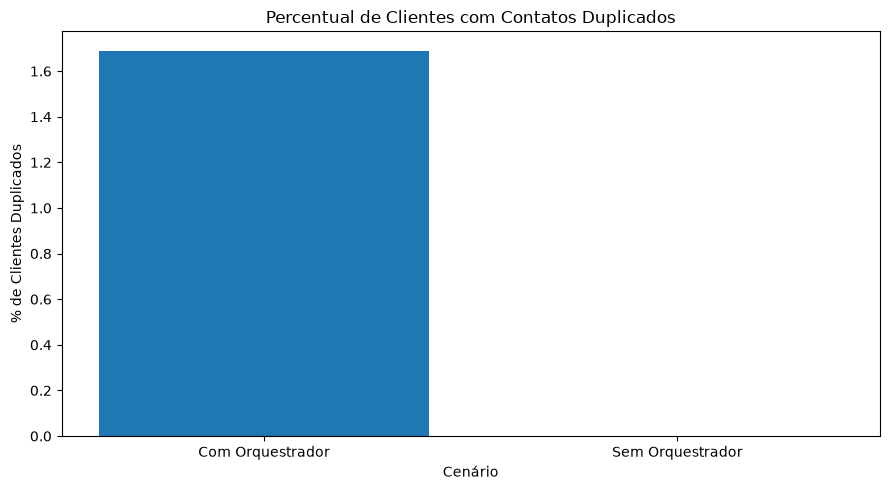

In [19]:
#Gráfico de clientes duplicados

plt.figure(figsize=(9, 5))

plt.bar(
    metricas_duplicidade["cenario"],
    metricas_duplicidade["percentual_clientes_duplicados"]
)

plt.title("Percentual de Clientes com Contatos Duplicados")
plt.xlabel("Cenário")
plt.ylabel("% de Clientes Duplicados")

plt.tight_layout()
plt.savefig(
    CAMINHO_GRAFICOS / "comparativo_duplicidade_clientes.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [20]:
#Calcular eficiência operacional

metricas_eficiencia = calcular_metricas_eficiencia(
    logs_simulacao
)

metricas_eficiencia

,cenario,total_interacoes,interacoes_em_momento_critico,vendas,respostas_whatsapp,nao_atendidos,percentual_momento_critico,taxa_venda,taxa_whatsapp,taxa_nao_atendido
0,Com Orquestrador,300,300,13,28,182,100.00,4.33,9.33,60.67
1,Sem Orquestrador,300,137,17,33,182,45.67,5.67,11.00,60.67


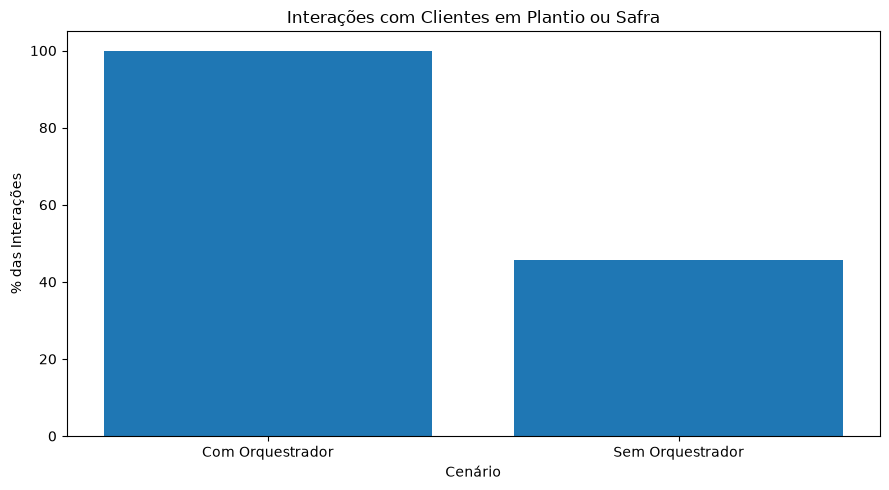

In [21]:
#Gráfico de interações em momento crítico

plt.figure(figsize=(9, 5))

plt.bar(
    metricas_eficiencia["cenario"],
    metricas_eficiencia["percentual_momento_critico"]
)

plt.title("Interações com Clientes em Plantio ou Safra")
plt.xlabel("Cenário")
plt.ylabel("% das Interações")

plt.tight_layout()
plt.savefig(
    CAMINHO_GRAFICOS / "comparativo_momento_critico.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

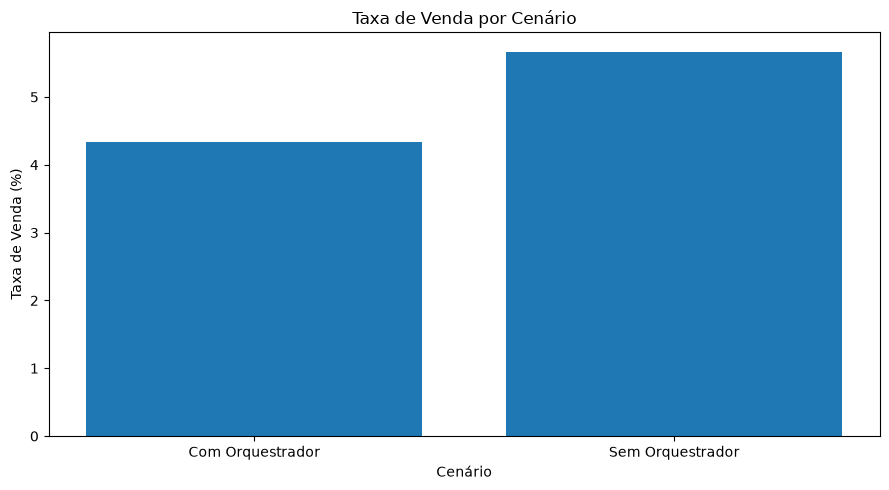

In [22]:
#Gráfico de taxa de venda

plt.figure(figsize=(9, 5))

plt.bar(
    metricas_eficiencia["cenario"],
    metricas_eficiencia["taxa_venda"]
)

plt.title("Taxa de Venda por Cenário")
plt.xlabel("Cenário")
plt.ylabel("Taxa de Venda (%)")

plt.tight_layout()
plt.savefig(
    CAMINHO_GRAFICOS / "comparativo_taxa_venda.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [23]:
#Interações por canal

interacoes_por_canal = (
    logs_simulacao
    .groupby(["cenario", "canal"])
    .agg(
        quantidade=("numero_interacao", "count")
    )
    .reset_index()
)

interacoes_por_canal

,cenario,canal,quantidade
0,Com Orquestrador,Humano,97
1,Com Orquestrador,Robô,203
2,Sem Orquestrador,Humano,105
3,Sem Orquestrador,Robô,195


In [24]:
#Resultado por cenário e canal

resultado_por_cenario_canal = (
    logs_simulacao
    .groupby(["cenario", "canal", "resultado"])
    .agg(
        quantidade=("numero_interacao", "count")
    )
    .reset_index()
    .sort_values(
        by=["cenario", "canal", "quantidade"],
        ascending=[True, True, False]
    )
)

resultado_por_cenario_canal

,cenario,canal,resultado,quantidade
1,Com Orquestrador,Humano,Não Atendido,48
0,Com Orquestrador,Humano,Atendido sem Venda,26
3,Com Orquestrador,Humano,Venda,13
2,Com Orquestrador,Humano,Resposta WhatsApp,10
5,Com Orquestrador,Robô,Não Atendido,134
4,Com Orquestrador,Robô,Atendido com Transferência,51
6,Com Orquestrador,Robô,Resposta WhatsApp,18
8,Sem Orquestrador,Humano,Não Atendido,53
7,Sem Orquestrador,Humano,Atendido sem Venda,25
10,Sem Orquestrador,Humano,Venda,17


In [25]:
#Carregar eventos gerados pela State Machine

consulta_eventos = """
SELECT
    id_evento,
    id_cliente,
    data_evento,
    canal,
    resultado,
    observacao
FROM eventos_contato
ORDER BY id_evento;
"""

eventos_state_machine = pd.read_sql_query(
    consulta_eventos,
    orquestrador.conexao
)

eventos_state_machine.head()

,id_evento,id_cliente,data_evento,canal,resultado,observacao
0,13,160499,2026-07-01 21:08:56,Robô,Não Atendido,Lead colocado em cooldown por 48 horas.
1,14,160499,2026-07-01 21:08:56,Sistema,Cooldown Aplicado,Cooldown válido até 2026-07-03 21:08:56.
2,15,940249,2026-07-01 21:08:57,Robô,Não Atendido,Lead colocado em cooldown por 48 horas.
3,16,940249,2026-07-01 21:08:57,Sistema,Cooldown Aplicado,Cooldown válido até 2026-07-03 21:08:57.
4,17,533299,2026-07-01 21:08:57,Robô,Não Atendido,Lead colocado em cooldown por 48 horas.


In [26]:
#Quantidade de eventos por resultado


eventos_por_resultado = (
    eventos_state_machine
    .groupby(["canal", "resultado"])
    .agg(
        quantidade=("id_evento", "count")
    )
    .reset_index()
    .sort_values(by="quantidade", ascending=False)
)

eventos_por_resultado


,canal,resultado,quantidade
5,Sistema,Cooldown Aplicado,182
4,Robô,Não Atendido,134
3,Robô,Atendido,51
6,Sistema,Transferência Assistida,51
1,Humano,Não Atendido,48
7,WhatsApp,Resposta WhatsApp,28
0,Humano,Atendido,26
2,Humano,Venda,13


In [27]:
#Eventos por cliente

eventos_por_cliente = (
    eventos_state_machine
    .groupby("id_cliente")
    .agg(
        quantidade_eventos=("id_evento", "count")
    )
    .reset_index()
    .sort_values(by="quantidade_eventos", ascending=False)
)

eventos_por_cliente.head(10)

,id_cliente,quantidade_eventos
31,11995,3
293,946249,2
1,447,2
2,694,2
294,946549,2
4,2599,2
277,871899,2
276,847849,2
274,839749,2
273,839499,2


In [28]:
#Salvar logs de simulação

CAMINHO_LOGS_SIMULACAO = CAMINHO_OUTPUTS / "logs_simulacao_operacao.csv"

logs_simulacao.to_csv(
    CAMINHO_LOGS_SIMULACAO,
    index=False,
    encoding="utf-8-sig"
)

print("Logs salvos em:", CAMINHO_LOGS_SIMULACAO)

Logs salvos em: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs\logs_simulacao_operacao.csv


In [29]:
#Salvar métricas

CAMINHO_METRICAS_DUPLICIDADE = CAMINHO_OUTPUTS / "metricas_duplicidade.csv"
CAMINHO_METRICAS_EFICIENCIA = CAMINHO_OUTPUTS / "metricas_eficiencia.csv"

metricas_duplicidade.to_csv(
    CAMINHO_METRICAS_DUPLICIDADE,
    index=False,
    encoding="utf-8-sig"
)

metricas_eficiencia.to_csv(
    CAMINHO_METRICAS_EFICIENCIA,
    index=False,
    encoding="utf-8-sig"
)

print("Métricas de duplicidade salvas em:", CAMINHO_METRICAS_DUPLICIDADE)
print("Métricas de eficiência salvas em:", CAMINHO_METRICAS_EFICIENCIA)

Métricas de duplicidade salvas em: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs\metricas_duplicidade.csv
Métricas de eficiência salvas em: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs\metricas_eficiencia.csv


In [30]:
#Criar resumo executivo

resumo_executivo = {
    "interacoes_simuladas_por_cenario": QUANTIDADE_INTERACOES,
    "total_logs_gerados": len(logs_simulacao),
    "eventos_auditaveis_state_machine": len(eventos_state_machine),
    "clientes_duplicados_sem_orquestrador_percentual": float(
        metricas_duplicidade.loc[
            metricas_duplicidade["cenario"] == "Sem Orquestrador",
            "percentual_clientes_duplicados"
        ].iloc[0]
    ),
    "clientes_duplicados_com_orquestrador_percentual": float(
        metricas_duplicidade.loc[
            metricas_duplicidade["cenario"] == "Com Orquestrador",
            "percentual_clientes_duplicados"
        ].iloc[0]
    ),
    "taxa_venda_sem_orquestrador": float(
        metricas_eficiencia.loc[
            metricas_eficiencia["cenario"] == "Sem Orquestrador",
            "taxa_venda"
        ].iloc[0]
    ),
    "taxa_venda_com_orquestrador": float(
        metricas_eficiencia.loc[
            metricas_eficiencia["cenario"] == "Com Orquestrador",
            "taxa_venda"
        ].iloc[0]
    )
}

resumo_executivo

{'interacoes_simuladas_por_cenario': 300,
 'total_logs_gerados': 600,
 'eventos_auditaveis_state_machine': 533,
 'clientes_duplicados_sem_orquestrador_percentual': 0.0,
 'clientes_duplicados_com_orquestrador_percentual': 1.69,
 'taxa_venda_sem_orquestrador': 5.67,
 'taxa_venda_com_orquestrador': 4.33}

In [31]:
#Salvar resumo executivo

CAMINHO_RESUMO_EXECUTIVO = CAMINHO_OUTPUTS / "resumo_executivo_simulacao.csv"

pd.DataFrame([resumo_executivo]).to_csv(
    CAMINHO_RESUMO_EXECUTIVO,
    index=False,
    encoding="utf-8-sig"
)

print("Resumo executivo salvo em:", CAMINHO_RESUMO_EXECUTIVO)

Resumo executivo salvo em: c:\Users\DataCore\Desktop\projetos_Git\agro-leads-orchestrator\outputs\resumo_executivo_simulacao.csv


## Conclusão da Simulação

A simulação demonstrou a diferença entre uma operação comercial desorganizada e uma operação controlada por uma máquina de estados.

No cenário sem orquestrador, os contatos são realizados sem controle centralizado, permitindo maior risco de duplicidade e baixa governança operacional.

No cenário com orquestrador, as regras de negócio reduzem contatos inconvenientes, aplicam cooldown, priorizam leads engajados via WhatsApp e direcionam clientes em momentos agrícolas críticos para atendimento mais qualificado.

Essa etapa comprova o valor operacional da solução proposta e cria uma base analítica para os próximos notebooks de Machine Learning e dashboard.

In [32]:
#Fechar conexão

orquestrador.fechar_conexao()

print("Conexão encerrada.")

Conexão encerrada.
